# Importing the Liberary 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt    
import seaborn as sns
import os
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.5) 

In [2]:
# importing the dataset
data1 = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name='Customer_Demographics') 

In [3]:
data2 = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name='Transaction_History')
data3 = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name='Customer_Service')
data4 = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name='Online_Activity')
data5 = pd.read_excel('Customer_Churn_Data_Large.xlsx',sheet_name='Churn_Status') 

In [4]:
# Customer Demographics
data1.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [5]:
print('Data Understanding: Customer Demographics')
print('Shape of the dataset:', data1.shape)
print('Columns in the dataset:', data1.columns) 
print('Duplicate rows:', data1.duplicated().sum())
print('Total Missing values in the dataset:', data1.isnull().sum().sum())

Data Understanding: Customer Demographics
Shape of the dataset: (1000, 5)
Columns in the dataset: Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 0


In [6]:
print('Info of the dataset:', data1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
Info of the dataset: None


In [7]:
print('Stats of the dataset:', data1.describe())

Stats of the dataset:         CustomerID          Age
count  1000.000000  1000.000000
mean    500.500000    43.267000
std     288.819436    15.242311
min       1.000000    18.000000
25%     250.750000    30.000000
50%     500.500000    43.000000
75%     750.250000    56.000000
max    1000.000000    69.000000


Outliers in the dataset:


Text(0.5, 1.0, 'Boxplot of Customer Demographics')

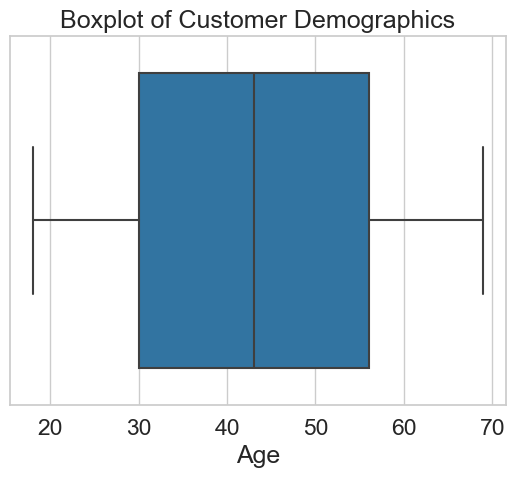

In [8]:
print('Outliers in the dataset:')
sns.boxplot(data=data1, x='Age')
plt.title('Boxplot of Customer Demographics')

Text(0.5, 1.0, 'Distribution of Age')

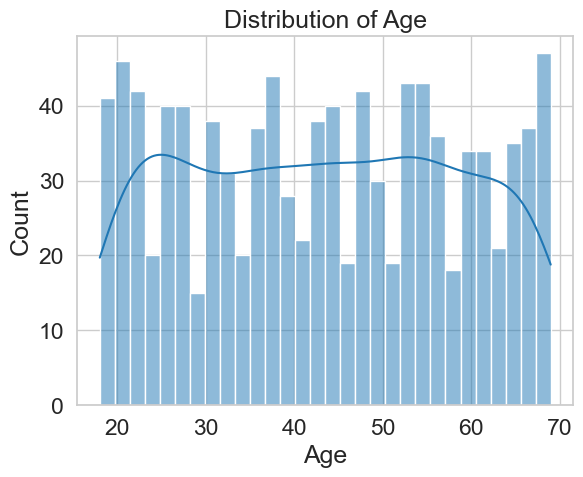

In [9]:
sns.histplot(data=data1, x='Age', kde=True,bins=30)
plt.title('Distribution of Age')

In [10]:
print("skewness of Age:", data1['Age'].skew())
print("kurtosis of Age:", data1['Age'].kurt()) 

skewness of Age: 0.013168103545372956
kurtosis of Age: -1.2129695174429682


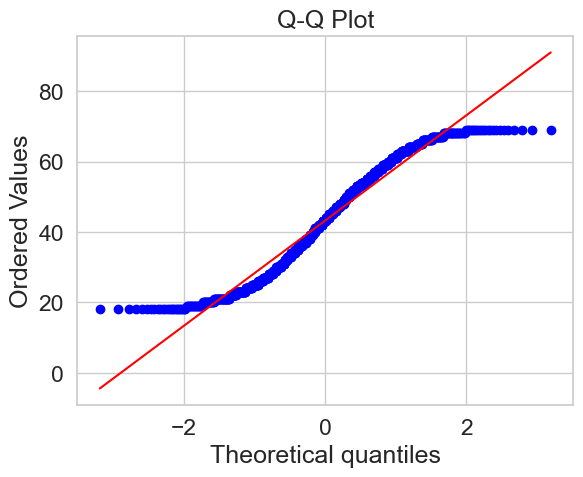

In [11]:
import scipy.stats as stats

stats.probplot(data1['Age'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


Text(0.5, 1.0, ' Distribution of Gender')

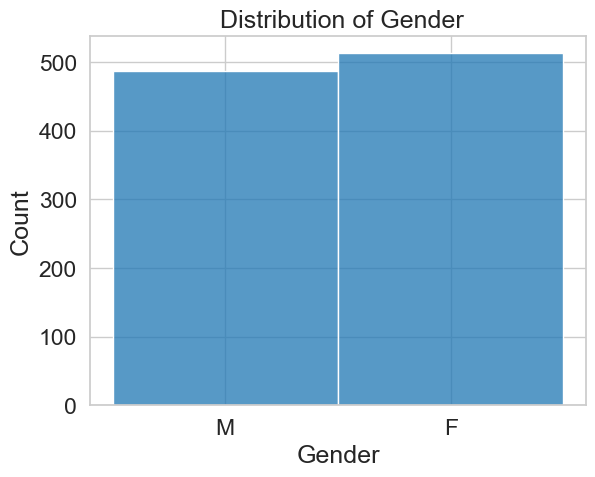

In [12]:
sns.histplot(data=data1, x='Gender')
plt.title(' Distribution of Gender')

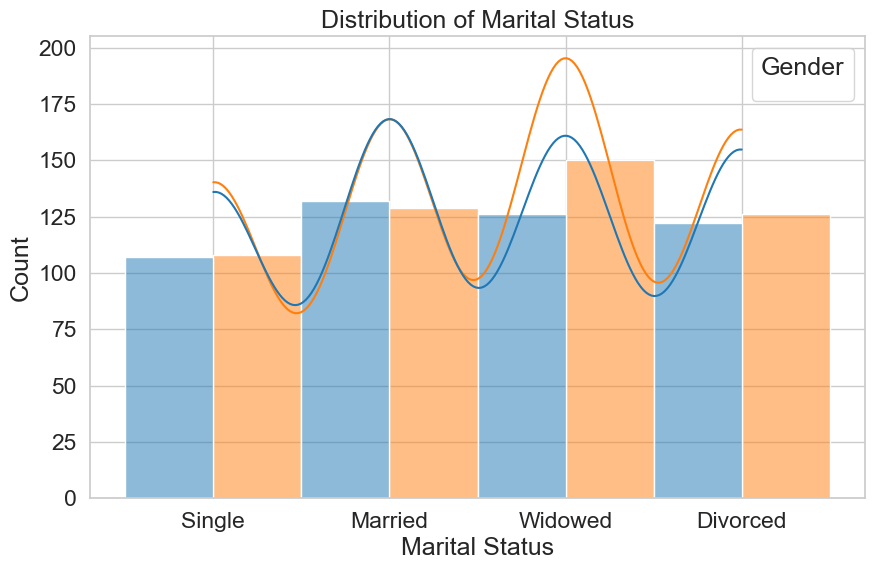

In [107]:
plt.figure(figsize=(10,6))
sns.histplot(data=data1, x='MaritalStatus', kde=True, hue='Gender', multiple='dodge')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Distribution of Marital Status')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Male (Blue)', 'Female (Orange)'], title='Gender')
plt.show()


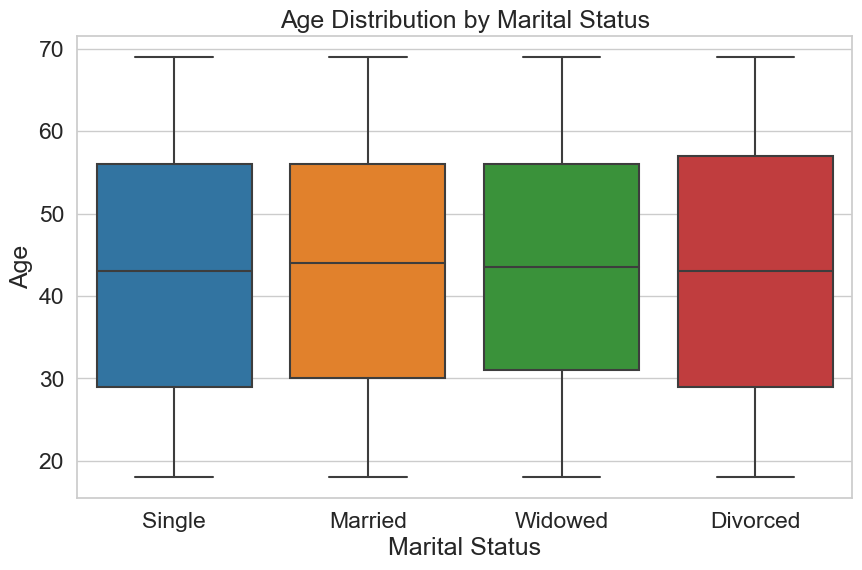

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data1, x='MaritalStatus', y='Age')
plt.xlabel('Marital Status')
plt.ylabel('Age')
plt.title('Age Distribution by Marital Status')
plt.show()

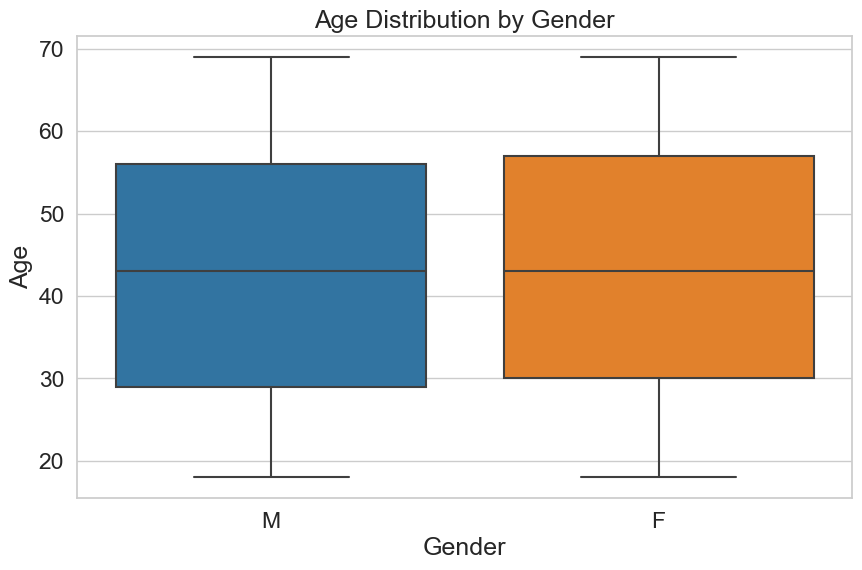

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data1, x='Gender', y='Age')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.title('Age Distribution by Gender')
plt.show()

### Insights from Customer Demographics

- The `Age` feature shows a clear central range with some outliers, making it useful for age-based segmentation and churn risk modeling.
- The `Gender` histogram provides a quick check of population balance, which is important for any gender-specific analysis or campaign targeting.
- The stacked `MaritalStatus` distribution by gender highlights how relationship status varies across male and female customers, which can inform retention and service strategies.
- The `Age vs MaritalStatus` boxplot reveals which marital categories tend to have older or younger customers, helping to align offers with customer life stages.
- Data quality checks for duplicates and missing values were performed, and the demographic dataset is clean enough to join with transaction and service data for further analysis.

In [16]:
# Transaction_History
data2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [17]:
print('Data understanding: Transaction History')
print('Shape of the dataset:', data2.shape)
print('columns in the dataset:', data2.columns )
print('Duplicate rows:', data2.duplicated().sum())
print('Total Missing values in the dataset:', data2.isnull().sum().sum())

Data understanding: Transaction History
Shape of the dataset: (5054, 5)
columns in the dataset: Index(['CustomerID', 'TransactionID', 'TransactionDate', 'AmountSpent',
       'ProductCategory'],
      dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 0


In [18]:
print("Infromation about the dataset:", data2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 197.6+ KB
Infromation about the dataset: None


In [19]:
print("Stats of the dataset:", data2.describe())

Stats of the dataset:         CustomerID  TransactionID                TransactionDate  AmountSpent
count  5054.000000    5054.000000                           5054  5054.000000
mean    501.424218    5510.538979  2022-07-01 19:25:37.158686208   250.707351
min       1.000000    1000.000000            2022-01-01 00:00:00     5.180000
25%     251.000000    3242.000000            2022-04-03 00:00:00   127.105000
50%     506.000000    5530.000000            2022-07-01 00:00:00   250.525000
75%     749.000000    7680.750000            2022-09-29 00:00:00   373.412500
max    1000.000000    9997.000000            2022-12-31 00:00:00   499.860000
std     285.172780    2582.088012                            NaN   142.250838


In [20]:
print('Skewness of Transaction Amount:', data2['AmountSpent'].skew())
print('Kurtosis of Transaction Amount:', data2['AmountSpent'].kurt())

Skewness of Transaction Amount: 0.012092577177959096
Kurtosis of Transaction Amount: -1.2020258458539834


Text(0.5, 1.0, 'Boxplot of Transaction Amount')

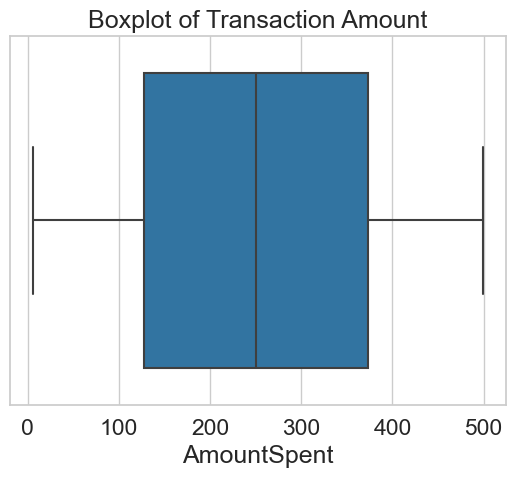

In [21]:
sns.boxplot(data=data2, x='AmountSpent')
plt.title('Boxplot of Transaction Amount')

Text(0.5, 1.0, 'Distribution of AmountSpent')

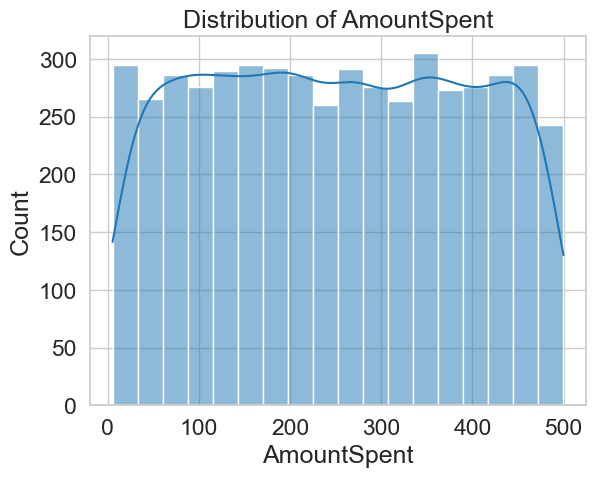

In [22]:
sns.histplot(data=data2, x='AmountSpent', kde=True)
plt.title('Distribution of AmountSpent')

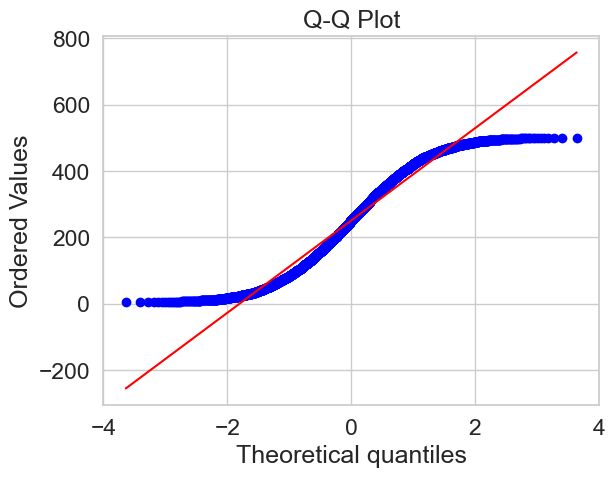

In [23]:
stats.probplot(data2['AmountSpent'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


Text(0.5, 0, 'Product Category')

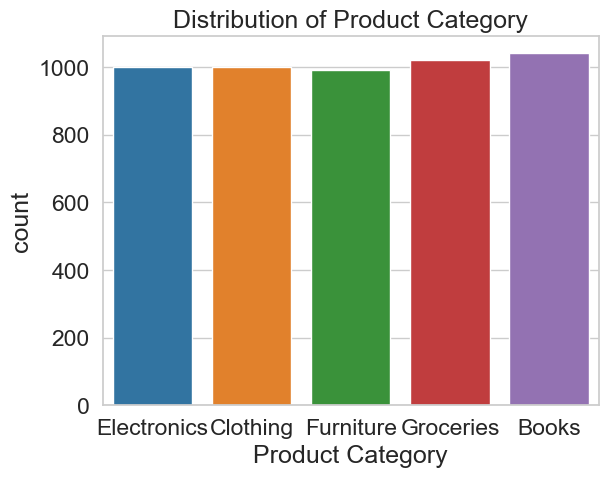

In [24]:
sns.countplot(data=data2, x='ProductCategory')
plt.title('Distribution of Product Category')
plt.xlabel('Product Category')

Text(0, 0.5, 'AMount Spent')

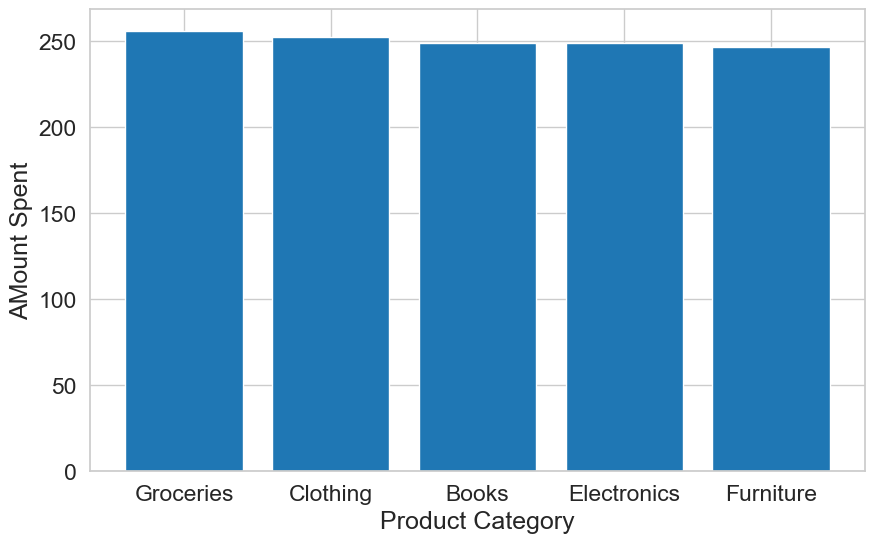

In [25]:
product_amount_by_category = data2.groupby('ProductCategory')['AmountSpent'].mean().reset_index().sort_values(by='AmountSpent', ascending=False)    
plt.figure(figsize=(10, 6))
plt.bar(product_amount_by_category['ProductCategory'], product_amount_by_category['AmountSpent'])
plt.xlabel('Product Category')
plt.ylabel("AMount Spent")


In [26]:
print(product_amount_by_category)

  ProductCategory  AmountSpent
4       Groceries   256.013382
1        Clothing   252.450700
0           Books   249.341969
2     Electronics   248.890899
3       Furniture   246.759899


In [27]:
data2['Year'] = data2['TransactionDate'].dt.year
data2['Month'] = data2['TransactionDate'].dt.month


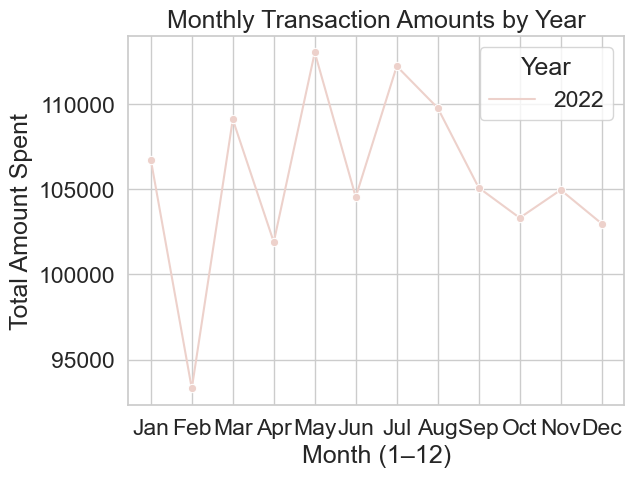

In [28]:
monthly_data = data2.groupby(['Year','Month'])['AmountSpent'].sum().reset_index()

# Plot with separate lines for each year
sns.lineplot(data=monthly_data, x='Month', y='AmountSpent', hue='Year', marker='o')
plt.title('Monthly Transaction Amounts by Year')
plt.xlabel('Month (1–12)')
plt.ylabel('Total Amount Spent')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


c:\Users\HIMANSHU VYAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


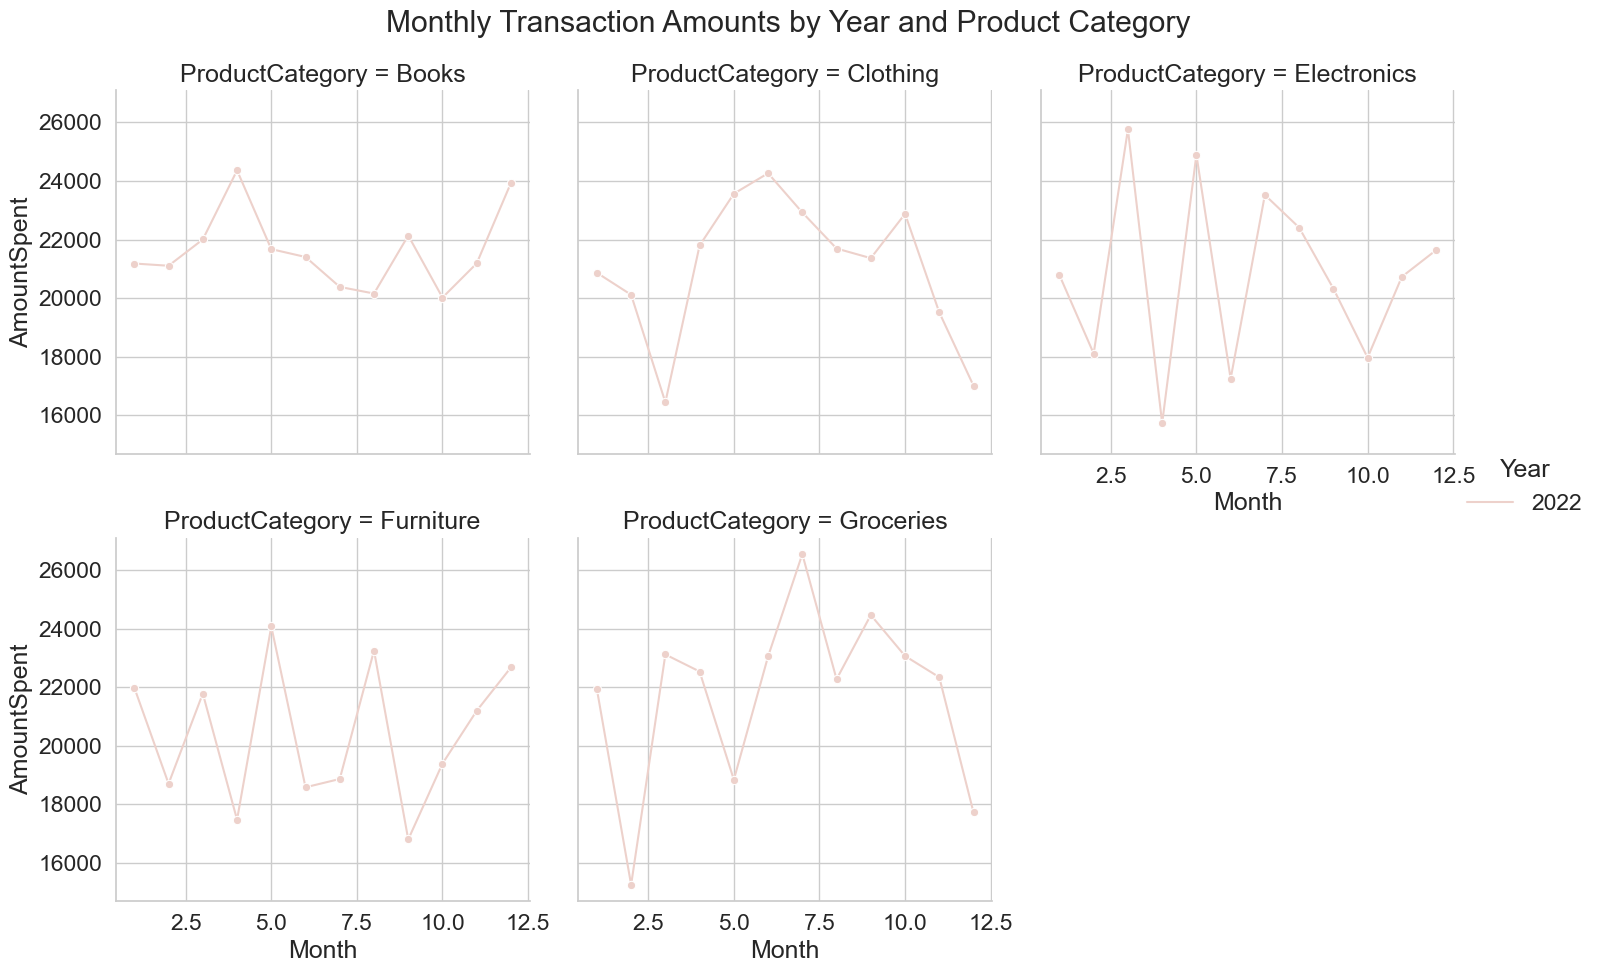

In [29]:

# Aggregate by Year, Month, and ProductCategory
monthly_data = (
    data2.groupby(['Year','Month','ProductCategory'])['AmountSpent']
    .sum()
    .reset_index()
)

# Plot: separate lines for each Year, split by ProductCategory
# Aggregate by Year, Month, and ProductCategory
monthly_data = (
    data2.groupby(['Year','Month','ProductCategory'])['AmountSpent']
    .sum()
    .reset_index()
)

# Plot: separate lines for each Year, split by ProductCategory
sns.relplot(
    data=monthly_data,
    x='Month',
    y='AmountSpent',
    hue='Year',
    col='ProductCategory',   # Separate chart per category
    kind='line',
    marker='o',
    col_wrap=3               # Wrap into multiple rows if many categories
)

plt.subplots_adjust(top=0.9)
plt.suptitle('Monthly Transaction Amounts by Year and Product Category')
plt.show()




Text(0.5, 1.0, 'Monthly Transaction Amounts by Year & Category')

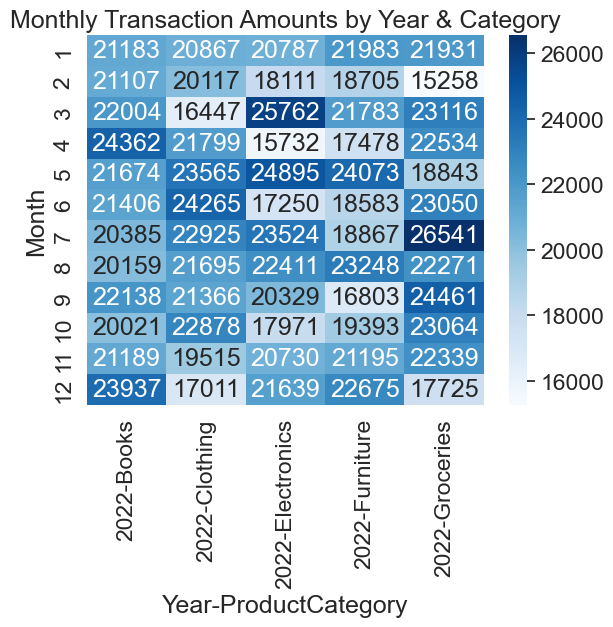

In [30]:
pivot_data = monthly_data.pivot_table(
    index='Month', columns=['Year','ProductCategory'], values='AmountSpent'
)

sns.heatmap(pivot_data, cmap='Blues', annot=True, fmt='.0f')
plt.title('Monthly Transaction Amounts by Year & Category')


In [31]:
# Customer_Service
data3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [32]:
print("Customer Service Data Understanding:")
print("Shape of the dataset:", data3.shape)
print("Columns in the dataset:", data3.columns)
print("Duplicate rows:", data3.duplicated().sum())
print("Total Missing values in the dataset:", data3.isnull().sum().sum())


Customer Service Data Understanding:
Shape of the dataset: (1002, 5)
Columns in the dataset: Index(['CustomerID', 'InteractionID', 'InteractionDate', 'InteractionType',
       'ResolutionStatus'],
      dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 0


In [33]:
print('Information about the dataset:', data3.info()  )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[ns]
 3   InteractionType   1002 non-null   object        
 4   ResolutionStatus  1002 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 39.3+ KB
Information about the dataset: None


Text(0.5, 1.0, 'Distribution of Interaction Types')

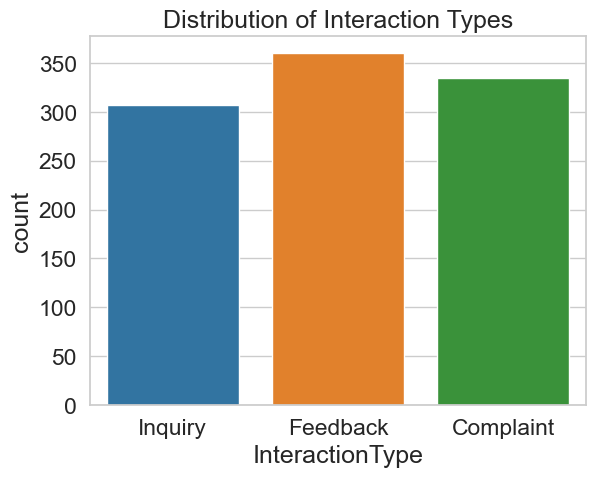

In [34]:
sns.countplot(data=data3, x='InteractionType')
plt.title('Distribution of Interaction Types')

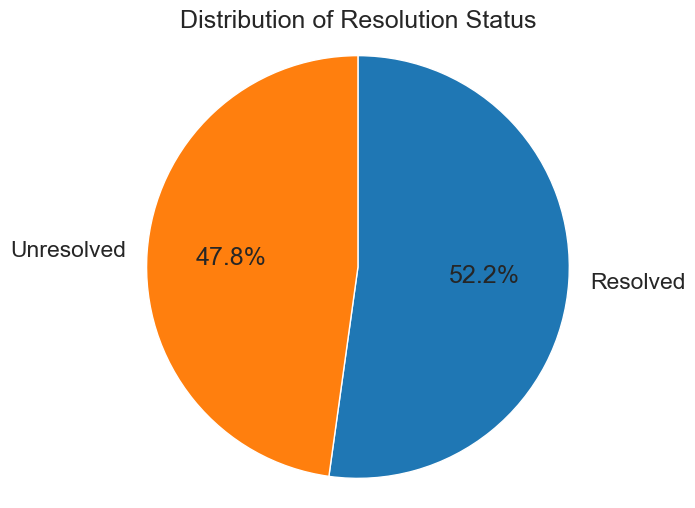

In [35]:
resolution_counts = data3['ResolutionStatus'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    resolution_counts,
    labels=resolution_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Distribution of Resolution Status')
plt.axis('equal')  # keep circle aspect
plt.show()

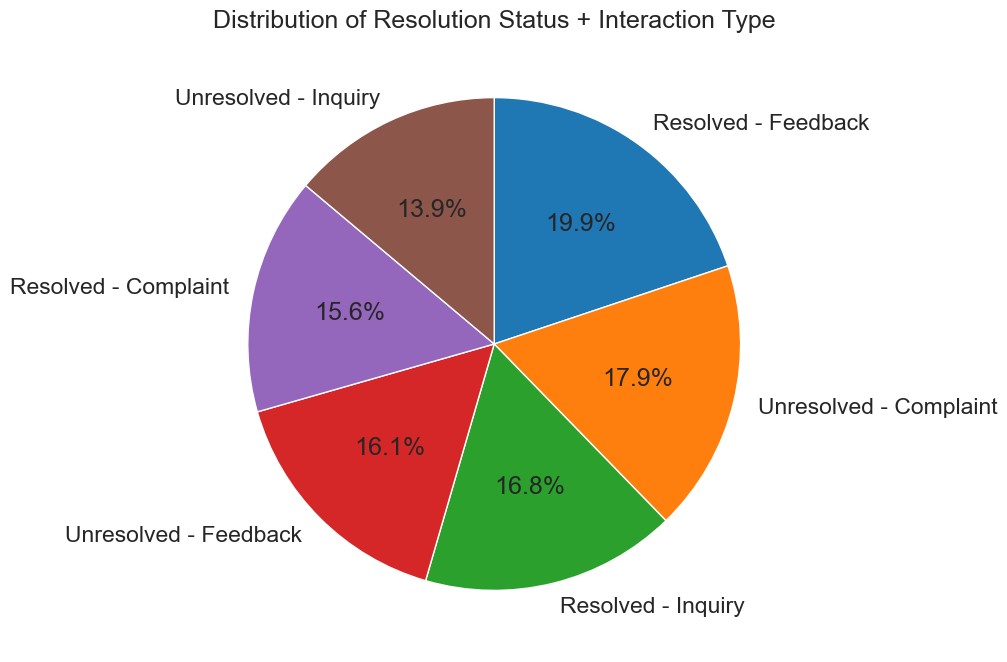

In [36]:
# Example: ResolutionStatus + InteractionType
# Create a combined column
data3['Status_Type'] = data3['ResolutionStatus'] + " - " + data3['InteractionType']

# Count occurrences
counts = data3['Status_Type'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Distribution of Resolution Status + Interaction Type')
plt.show()


In [37]:
# Online_Activity
data4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [38]:
print("data4 understanding: Online Activity")
print("Shape of the dataset:", data4.shape)
print("Columns in the dataset:", data4.columns)
print("Duplicate rows:", data4.duplicated().sum())
print("Total Missing values in the dataset:", data4.isnull().sum().sum())  


data4 understanding: Online Activity
Shape of the dataset: (1000, 4)
Columns in the dataset: Index(['CustomerID', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage'], dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 0


In [39]:
print("Information about the dataset:", data4.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   LastLoginDate   1000 non-null   datetime64[ns]
 2   LoginFrequency  1000 non-null   int64         
 3   ServiceUsage    1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 31.4+ KB
Information about the dataset: None


In [40]:
print("Stats of the dataset:", data4.describe())

Stats of the dataset:         CustomerID        LastLoginDate  LoginFrequency
count  1000.000000                 1000     1000.000000
mean    500.500000  2023-07-05 21:28:48       25.912000
min       1.000000  2023-01-01 00:00:00        1.000000
25%     250.750000  2023-04-08 00:00:00       13.750000
50%     500.500000  2023-07-10 12:00:00       27.000000
75%     750.250000  2023-10-01 06:00:00       38.000000
max    1000.000000  2023-12-31 00:00:00       49.000000
std     288.819436                  NaN       14.055953


In [41]:
print('Skewness of Online Activity:', data4['LoginFrequency'].skew())
print('Kurtosis of Online Activity:', data4['LoginFrequency'].kurt())

Skewness of Online Activity: -0.12787740941651965
Kurtosis of Online Activity: -1.1803380705125133


Text(0.5, 1.0, 'Distribution of Login Frequency')

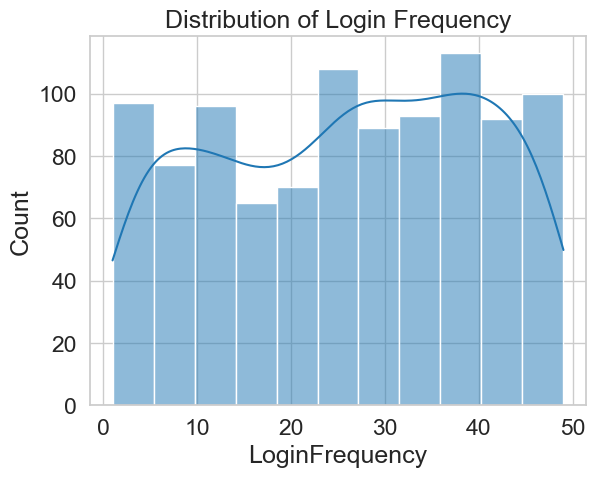

In [42]:
sns.histplot(data=data4, x='LoginFrequency', kde=True)
plt.title('Distribution of Login Frequency')

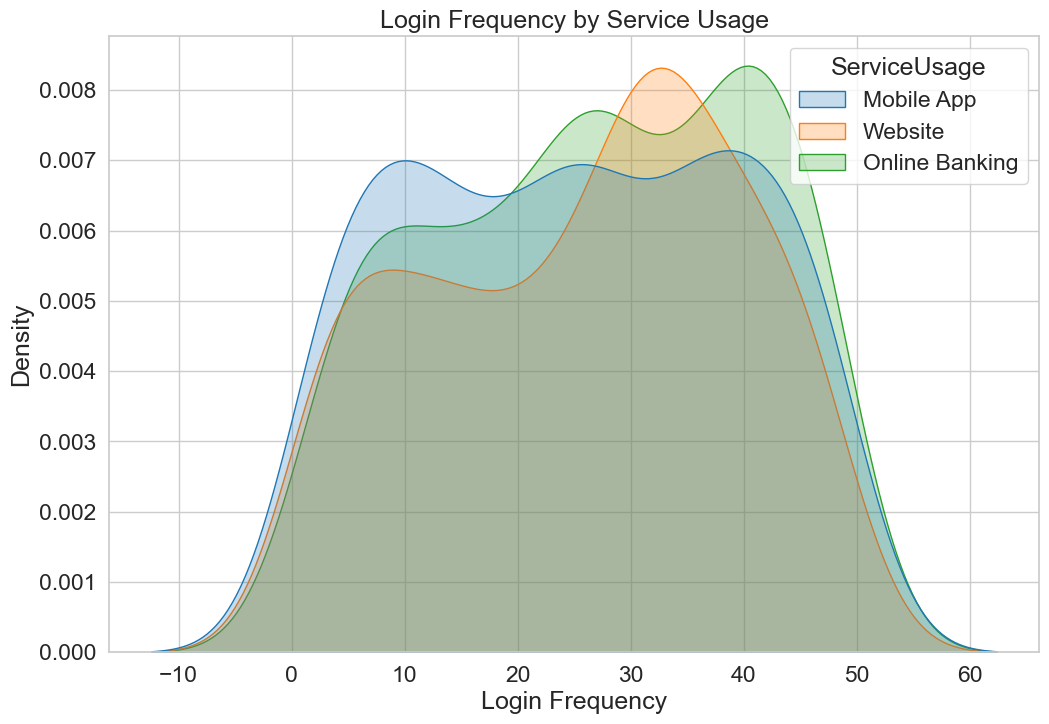

In [43]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=data4, x='LoginFrequency', hue='ServiceUsage', fill=True)
plt.title('Login Frequency by Service Usage')
plt.xlabel('Login Frequency')
plt.ylabel('Density')
plt.show()

Text(0.5, 1.0, 'Distribution of Service Usage')

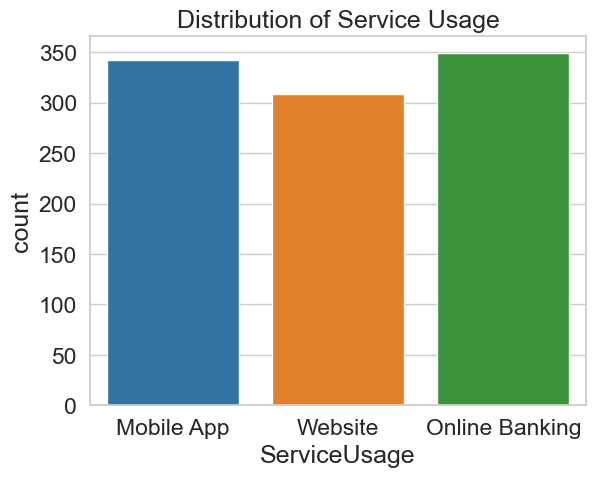

In [44]:
sns.countplot(data=data4, x='ServiceUsage')
plt.title('Distribution of Service Usage')

In [45]:
data4.groupby('ServiceUsage').agg({'LoginFrequency': 'sum'})

,LoginFrequency
ServiceUsage,
Mobile App,8565
Online Banking,9375
Website,7972


In [46]:
# Churn status
data5.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [47]:
print("Data Understanding: Online Activity")
print("Shape of the dataset:", data5.shape)
print("Columns in the dataset:", data5.columns)
print("Duplicate rows:", data5.duplicated().sum())
print("Total Missing values in the dataset:", data5.isnull().sum().sum())

Data Understanding: Online Activity
Shape of the dataset: (1000, 2)
Columns in the dataset: Index(['CustomerID', 'ChurnStatus'], dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 0


Text(0.5, 1.0, 'Distribution of Churn Status')

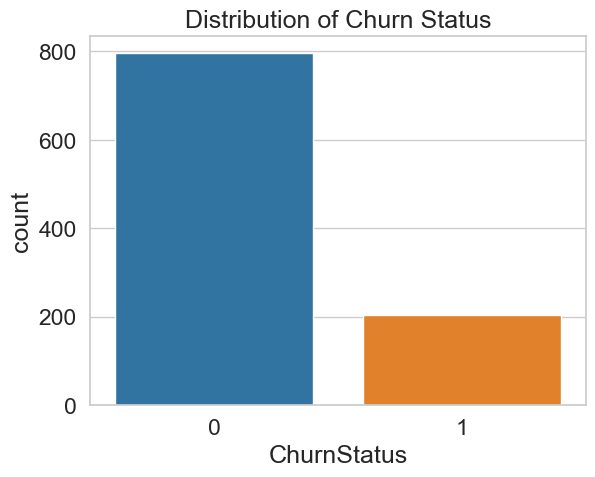

In [48]:
sns.countplot(data=data5, x='ChurnStatus')
plt.title('Distribution of Churn Status')

 # Data Merging and Preparation for Modeling

In [49]:
print("Data For Modeling !")

Data For Modeling !


In [50]:
data2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Year,Month
0,1,7194,2022-03-27,416.50,Electronics,2022,3
1,2,7250,2022-08-08,54.96,Clothing,2022,8
2,2,9660,2022-07-25,197.50,Electronics,2022,7
3,2,2998,2022-01-25,101.31,Furniture,2022,1
4,2,1228,2022-07-24,397.37,Clothing,2022,7


In [51]:
data3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus,Status_Type
0,1,6363,2022-03-31,Inquiry,Resolved,Resolved - Inquiry
1,2,3329,2022-03-17,Inquiry,Resolved,Resolved - Inquiry
2,3,9976,2022-08-24,Inquiry,Resolved,Resolved - Inquiry
3,4,7354,2022-11-18,Inquiry,Resolved,Resolved - Inquiry
4,4,5393,2022-07-03,Inquiry,Unresolved,Unresolved - Inquiry


In [52]:
data4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [53]:
data1.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [54]:
data3 = data3[[
    'CustomerID',
    'InteractionID',
    'InteractionDate',
    'InteractionType',
    'ResolutionStatus'
]]

In [55]:
# merging the datasets

In [56]:
df_1 = pd.merge(data1, data2, on='CustomerID', how='left')
df_2 = pd.merge(df_1, data3, on='CustomerID', how='left')
df_3 = pd.merge(df_2, data4, on='CustomerID', how='left')
final_df = pd.merge(df_3, data5, on='CustomerID', how='left')

In [57]:
df_1.head(20)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,Year,Month
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,2022,3
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,2022,8
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,2022,7
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,2022,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,2022,7
5,2,65,M,Married,Low,8903,2022-01-09,285.21,Electronics,2022,1
6,2,65,M,Married,Low,3527,2022-09-16,311.34,Electronics,2022,9
7,2,65,M,Married,Low,9279,2022-11-19,199.73,Groceries,2022,11
8,3,18,M,Single,Low,9839,2022-10-08,241.06,Books,2022,10
9,3,18,M,Single,Low,7364,2022-08-15,51.07,Clothing,2022,8


In [58]:
final_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,Year,Month,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,2022,3,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,2022,8,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,2022,1,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [59]:
df=final_df.copy() # creating a copy of the final dataset for further analysis and modeling

In [60]:
# Data is Properley Merged and Ready for Analysis and Modeling

In [61]:
print("Data Understanding:")
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)
print("Duplicate rows:", df.duplicated().sum())
print("Total Missing values in the dataset:", df.isnull().sum().sum())

Data Understanding:
Shape of the dataset: (6812, 19)
Columns in the dataset: Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'TransactionID', 'TransactionDate', 'AmountSpent', 'ProductCategory',
       'Year', 'Month', 'InteractionID', 'InteractionDate', 'InteractionType',
       'ResolutionStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage',
       'ChurnStatus'],
      dtype='object')
Duplicate rows: 0
Total Missing values in the dataset: 6432


In [62]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
Year                   0
Month                  0
InteractionID       1608
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
dtype: int64

In [63]:
df.head(5)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,Year,Month,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,2022,3,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,2022,8,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,2022,1,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [64]:
# Find the last date in your dataset
max_date = df['InteractionDate'].max()

# Calculate days since last interaction relative to dataset end
df['DaysSinceLastInteraction'] = (max_date - df['InteractionDate']).dt.days.fillna(-1)

In [65]:
# Replace NaN with -1 (or another placeholder) before converting
df['DaysSinceLastInteraction'] = df['DaysSinceLastInteraction'].astype(int)

In [66]:
df.isnull().sum()  

CustomerID                     0
Age                            0
Gender                         0
MaritalStatus                  0
IncomeLevel                    0
TransactionID                  0
TransactionDate                0
AmountSpent                    0
ProductCategory                0
Year                           0
Month                          0
InteractionID               1608
InteractionDate             1608
InteractionType             1608
ResolutionStatus            1608
LastLoginDate                  0
LoginFrequency                 0
ServiceUsage                   0
ChurnStatus                    0
DaysSinceLastInteraction       0
dtype: int64

In [67]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,Year,Month,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastInteraction
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,2022,3,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0,274
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,2022,8,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1,288
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1,288
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,2022,1,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1,288
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,2022,7,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1,288


In [68]:
# After feature engineering
df = df.drop(columns=['InteractionDate','InteractionID'])

In [69]:
df['InteractionType'] = df['InteractionType'].fillna('NoInteraction')
df['ResolutionStatus'] = df['ResolutionStatus'].fillna('NoInteraction')

In [70]:
df.isnull().sum()

CustomerID                  0
Age                         0
Gender                      0
MaritalStatus               0
IncomeLevel                 0
TransactionID               0
TransactionDate             0
AmountSpent                 0
ProductCategory             0
Year                        0
Month                       0
InteractionType             0
ResolutionStatus            0
LastLoginDate               0
LoginFrequency              0
ServiceUsage                0
ChurnStatus                 0
DaysSinceLastInteraction    0
dtype: int64

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                6812 non-null   int64         
 1   Age                       6812 non-null   int64         
 2   Gender                    6812 non-null   object        
 3   MaritalStatus             6812 non-null   object        
 4   IncomeLevel               6812 non-null   object        
 5   TransactionID             6812 non-null   int64         
 6   TransactionDate           6812 non-null   datetime64[ns]
 7   AmountSpent               6812 non-null   float64       
 8   ProductCategory           6812 non-null   object        
 9   Year                      6812 non-null   int32         
 10  Month                     6812 non-null   int32         
 11  InteractionType           6812 non-null   object        
 12  ResolutionStatus    

In [72]:
# Define the desired column order
ordered_cols = [
    'CustomerID',
    'Age',
    'Gender',
    'MaritalStatus',
    'IncomeLevel',
    'LastLoginDate',
    'LoginFrequency',
    'ServiceUsage',
    
    'TransactionID',
    'TransactionDate',
    'Year',
    'Month',
    'AmountSpent',
    'ProductCategory',
    
    'InteractionType',
    'ResolutionStatus',
    'DaysSinceLastInteraction',
    
    'ChurnStatus'
]

# Reorder dataframe
df = df[ordered_cols]

In [73]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,TransactionID,TransactionDate,Year,Month,AmountSpent,ProductCategory,InteractionType,ResolutionStatus,DaysSinceLastInteraction,ChurnStatus
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,7194,2022-03-27,2022,3,416.50,Electronics,Inquiry,Resolved,274,0
1,2,65,M,Married,Low,2023-12-05,5,Website,7250,2022-08-08,2022,8,54.96,Clothing,Inquiry,Resolved,288,1
2,2,65,M,Married,Low,2023-12-05,5,Website,9660,2022-07-25,2022,7,197.50,Electronics,Inquiry,Resolved,288,1
3,2,65,M,Married,Low,2023-12-05,5,Website,2998,2022-01-25,2022,1,101.31,Furniture,Inquiry,Resolved,288,1
4,2,65,M,Married,Low,2023-12-05,5,Website,1228,2022-07-24,2022,7,397.37,Clothing,Inquiry,Resolved,288,1


In [74]:
df.isnull().sum().sum() # No missing values after preprocessing 

0

In [75]:
# Now the dataset is clean and ready for EDA and Modeling

In [76]:
total_customers = df['CustomerID'].nunique()
print("Total unique customers:", total_customers)

Total unique customers: 1000


In [77]:
print('Age and Gender Churn Analysis')

Age and Gender Churn Analysis


In [78]:

# Define bins and labels
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25','26-35','36-45','46-55','56-65','66+']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)
 

<Figure size 1000x600 with 0 Axes>

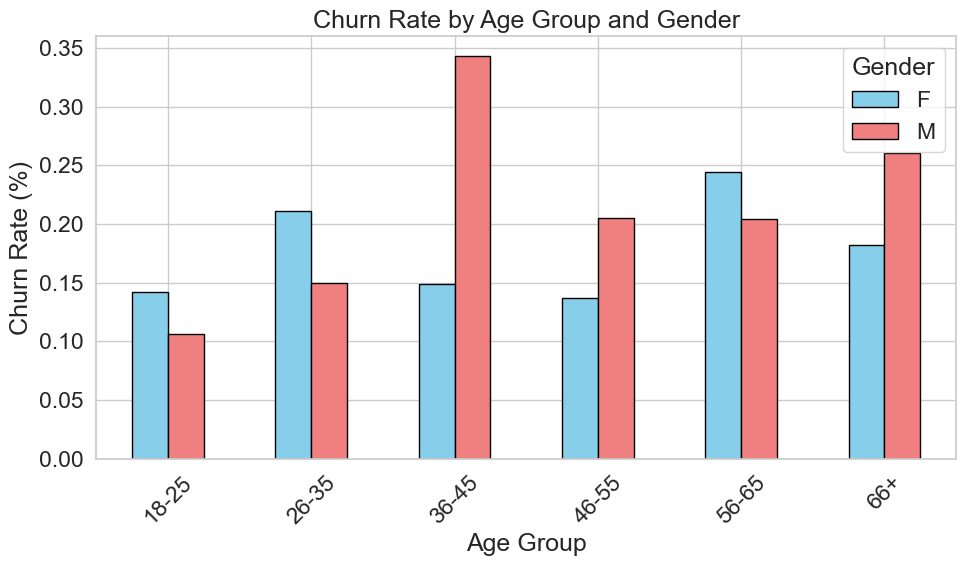

In [79]:
churn_by_age_gender = df.groupby(['AgeGroup','Gender'])['ChurnStatus'].mean().unstack()
plt.figure(figsize=(10,6))
churn_by_age_gender.plot(kind='bar', figsize=(10,6), 
                         color=['skyblue','lightcoral'], edgecolor='black')

plt.title('Churn Rate by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


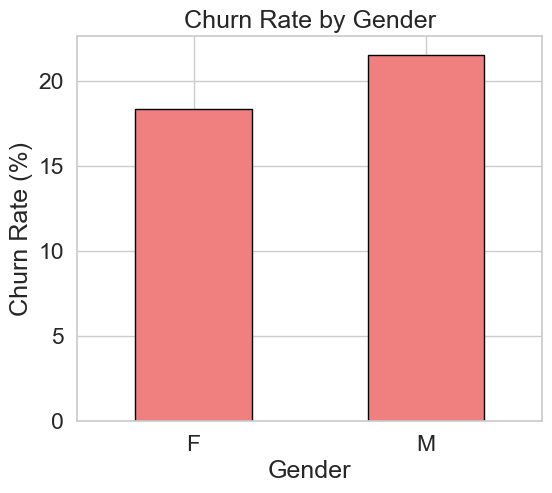

In [80]:
churn_by_gender = df.groupby('Gender')['ChurnStatus'].mean() * 100
plt.figure(figsize=(6,5))
churn_by_gender.plot(kind='bar', color='lightcoral', edgecolor='black')

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [81]:
print('Marital Status, Income and Churn Analysis')

Marital Status, Income and Churn Analysis


<Figure size 1000x600 with 0 Axes>

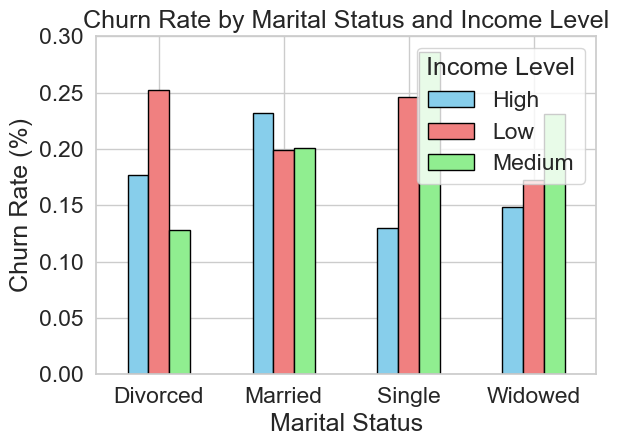

In [82]:
churn_grouped = df.groupby(['MaritalStatus','IncomeLevel'])['ChurnStatus'].mean().unstack()
plt.figure(figsize=(10,6))
churn_grouped.plot(kind='bar', edgecolor='black', color=['skyblue','lightcoral','lightgreen'])

plt.title('Churn Rate by Marital Status and Income Level')
plt.xlabel('Marital Status')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Income Level')
plt.tight_layout()
plt.show()

In [83]:
print('Login Frequency, Service Usage and Churn Analysis')

Login Frequency, Service Usage and Churn Analysis


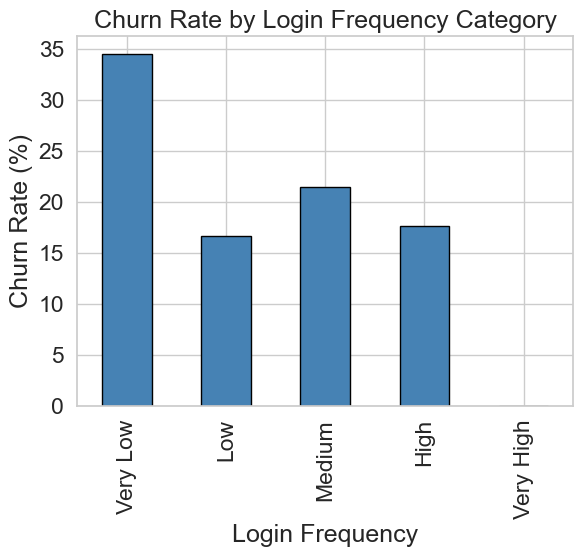

In [84]:
df['LoginCategory'] = pd.cut(
    df['LoginFrequency'],
    bins=[0, 5, 10, 20, 50, 100],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
churn_by_login = df.groupby('LoginCategory')['ChurnStatus'].mean() * 100
churn_by_login.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Churn Rate by Login Frequency Category')
plt.xlabel('Login Frequency')
plt.ylabel('Churn Rate (%)')
plt.show()

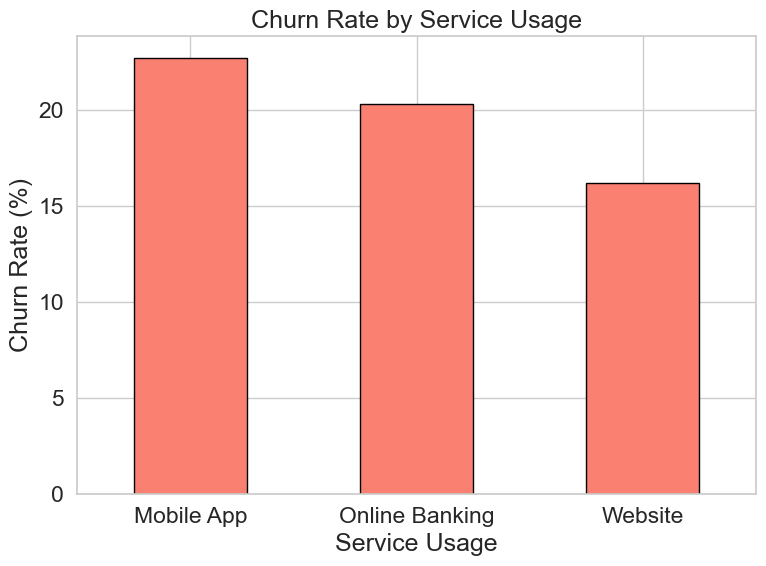

In [85]:
# Group by ServiceUsage and calculate churn rate
churn_by_service = df.groupby('ServiceUsage')['ChurnStatus'].mean() * 100

# Plot bar chart
plt.figure(figsize=(8,6))
churn_by_service.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Churn Rate by Service Usage')
plt.xlabel('Service Usage')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [86]:
print("Monthly Analysis of Churn Rate")

Monthly Analysis of Churn Rate


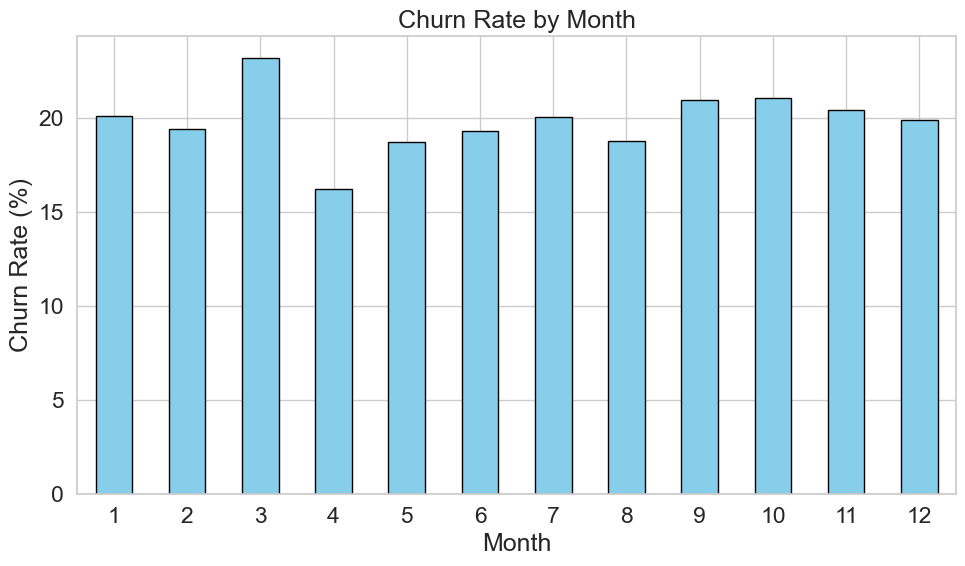

In [87]:
# Group by Month and calculate churn rate
churn_by_month = df.groupby('Month')['ChurnStatus'].mean() * 100

# Sort months in calendar order if Month is numeric (1–12)
month_order = list(range(1,13))
churn_by_month = churn_by_month.reindex(month_order)

# Plot bar chart
plt.figure(figsize=(10,6))
churn_by_month.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Churn Rate by Month')
plt.xlabel('Month')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [88]:
print('Total Amount , Product Category and Churn Analysis')

Total Amount , Product Category and Churn Analysis


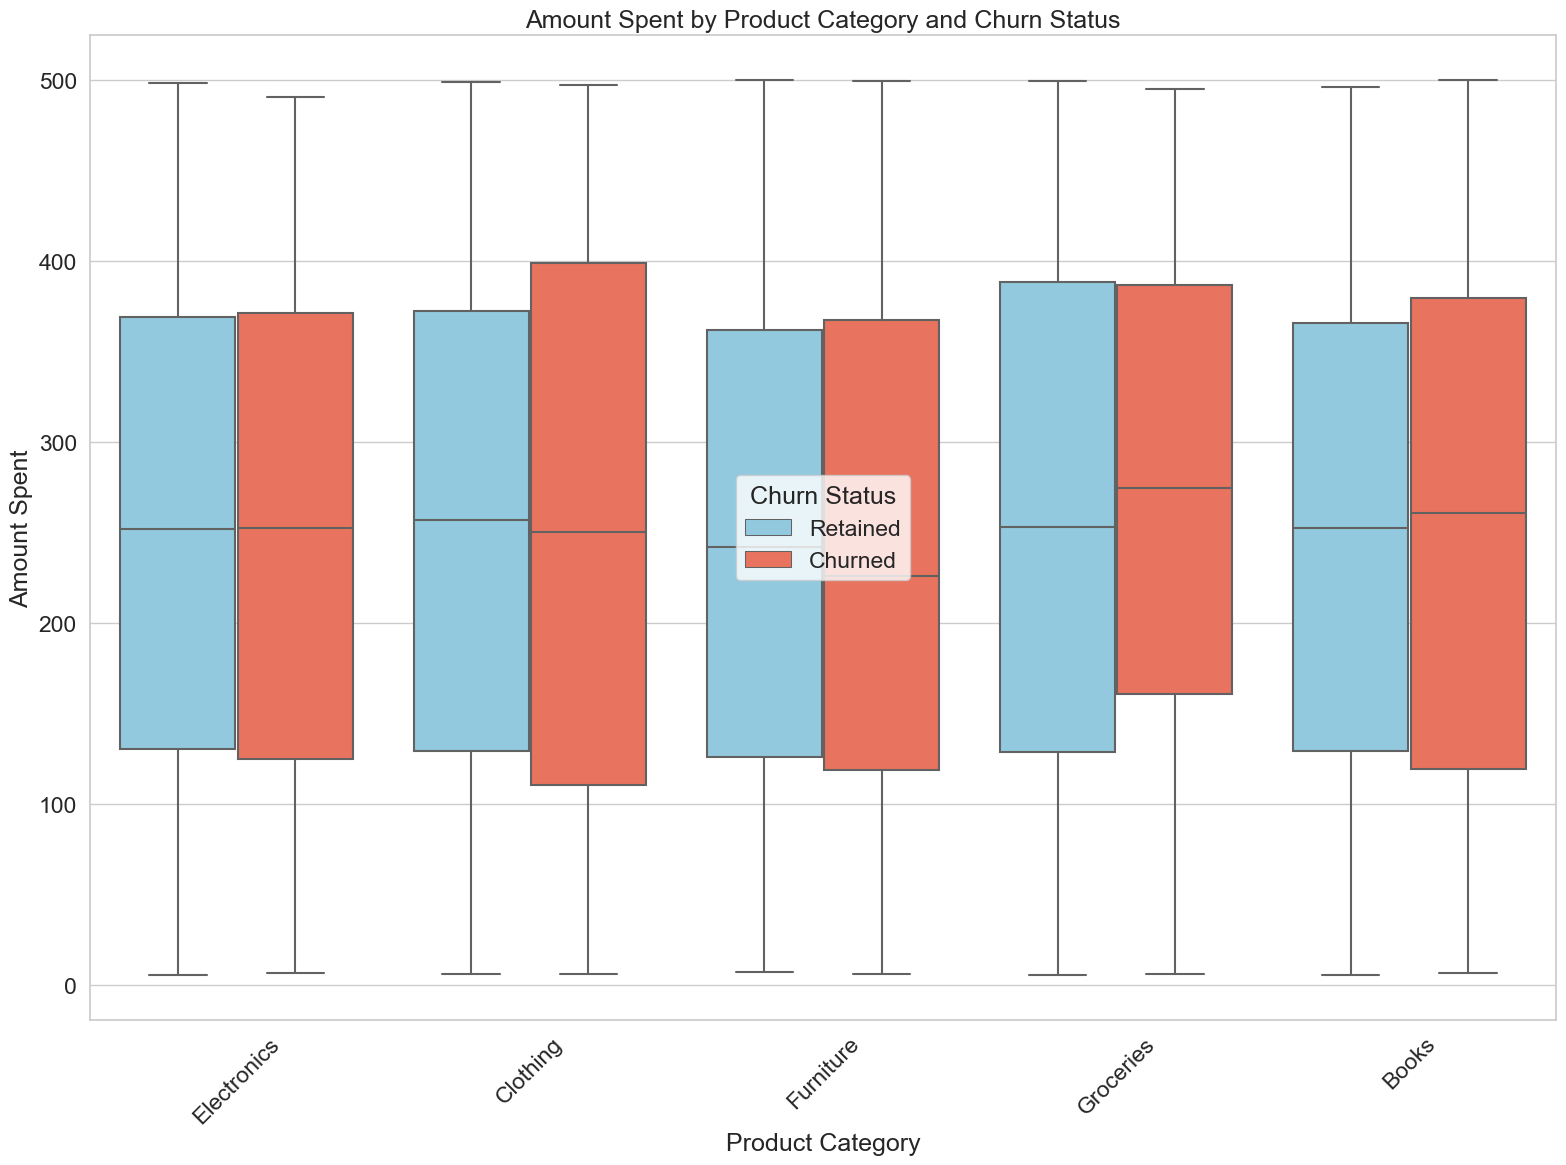

In [89]:
# Explicit mapping for churn status
custom_palette = {0: "skyblue", 1: "tomato"}

plt.figure(figsize=(16,12))
sns.boxplot(x='ProductCategory', y='AmountSpent', hue='ChurnStatus',
            data=df, palette=custom_palette)

plt.title('Amount Spent by Product Category and Churn Status')
plt.xlabel('Product Category')
plt.ylabel('Amount Spent')
plt.xticks(rotation=45)

# Fix legend labels and colors
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Retained','Churned'], title='Churn Status')

plt.tight_layout()
plt.show()


In [90]:
print('Churn Rate by Interaction Type and Resolution Status')

Churn Rate by Interaction Type and Resolution Status


<Figure size 1000x600 with 0 Axes>

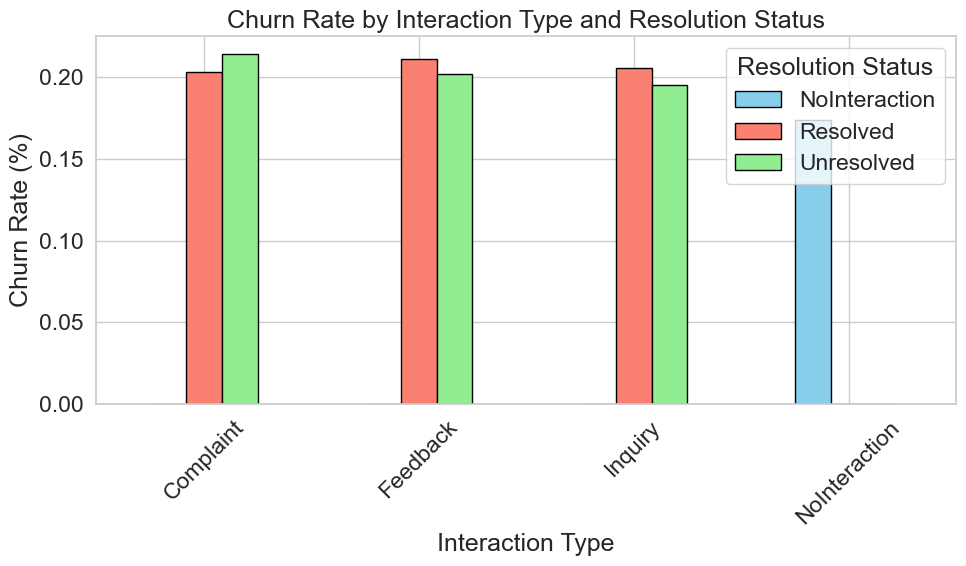

In [91]:
# Group by InteractionType and ResolutionStatus, calculate churn rate
churn_interaction = df.groupby(['InteractionType','ResolutionStatus'])['ChurnStatus'].mean().unstack()

# Plot grouped bar chart
plt.figure(figsize=(10,6))
churn_interaction.plot(kind='bar', edgecolor='black', figsize=(10,6),
                       color=['skyblue','salmon','lightgreen'])

plt.title('Churn Rate by Interaction Type and Resolution Status')
plt.xlabel('Interaction Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Resolution Status')
plt.tight_layout()
plt.show()


In [92]:
print('Churn Rate by Days Since Last Interaction')

Churn Rate by Days Since Last Interaction


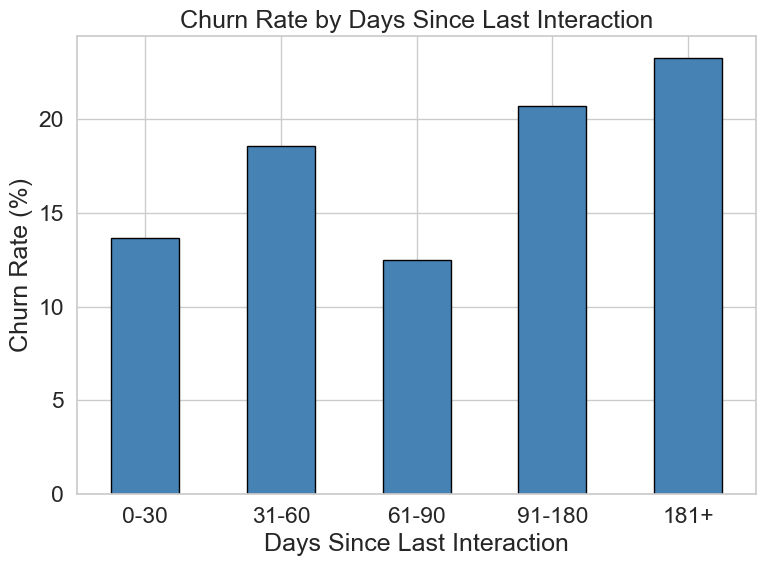

In [93]:
# Define bins for days since last interaction
bins = [0, 30, 60, 90, 180, float('inf')]
labels = ['0-30', '31-60', '61-90', '91-180', '181+']

# Create interaction bins
df['InteractionBin'] = pd.cut(df['DaysSinceLastInteraction'], bins=bins, labels=labels, right=True)

# Calculate churn rate per bin
churn_by_bin = df.groupby('InteractionBin')['ChurnStatus'].mean() * 100

# Plot bar chart
plt.figure(figsize=(8,6))
churn_by_bin.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Churn Rate by Days Since Last Interaction')
plt.xlabel('Days Since Last Interaction')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


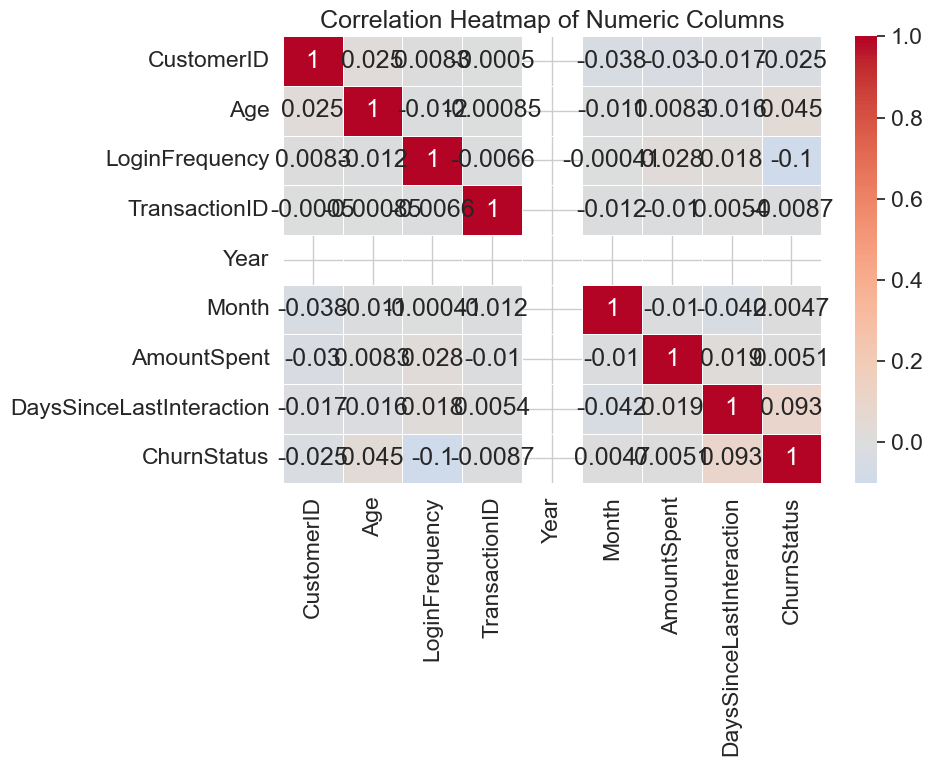

In [94]:
numeric_df = df.select_dtypes(include=['int64','float64','int32'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Columns')
plt.tight_layout()
plt.show()


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                6812 non-null   int64         
 1   Age                       6812 non-null   int64         
 2   Gender                    6812 non-null   object        
 3   MaritalStatus             6812 non-null   object        
 4   IncomeLevel               6812 non-null   object        
 5   LastLoginDate             6812 non-null   datetime64[ns]
 6   LoginFrequency            6812 non-null   int64         
 7   ServiceUsage              6812 non-null   object        
 8   TransactionID             6812 non-null   int64         
 9   TransactionDate           6812 non-null   datetime64[ns]
 10  Year                      6812 non-null   int32         
 11  Month                     6812 non-null   int32         
 12  AmountSpent         

In [96]:
df_final = df.copy() # creating a copy of the final dataset for further analysis and modeling

In [97]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,TransactionID,TransactionDate,...,Month,AmountSpent,ProductCategory,InteractionType,ResolutionStatus,DaysSinceLastInteraction,ChurnStatus,AgeGroup,LoginCategory,InteractionBin
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,7194,2022-03-27,...,3,416.50,Electronics,Inquiry,Resolved,274,0,56-65,High,181+
1,2,65,M,Married,Low,2023-12-05,5,Website,7250,2022-08-08,...,8,54.96,Clothing,Inquiry,Resolved,288,1,56-65,Very Low,181+
2,2,65,M,Married,Low,2023-12-05,5,Website,9660,2022-07-25,...,7,197.50,Electronics,Inquiry,Resolved,288,1,56-65,Very Low,181+
3,2,65,M,Married,Low,2023-12-05,5,Website,2998,2022-01-25,...,1,101.31,Furniture,Inquiry,Resolved,288,1,56-65,Very Low,181+
4,2,65,M,Married,Low,2023-12-05,5,Website,1228,2022-07-24,...,7,397.37,Clothing,Inquiry,Resolved,288,1,56-65,Very Low,181+


In [98]:
df=df.drop(columns=['TransactionID','CustomerID','AgeGroup','LoginCategory','InteractionBin'])   

In [99]:
df.to_csv('churn_data.csv', index=False)

print("CSV file saved as churn_data.csv")


CSV file saved as churn_data.csv
